In [14]:
%load_ext autoreload
%autoreload 2

# !export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import os
# os.chdir('D:/thesis_code/keypoint_matcher')
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.cuda.empty_cache()

# Check Data Module

In [16]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')
dl = dm.train_dataloader()

references.shape=torch.Size([40, 2])


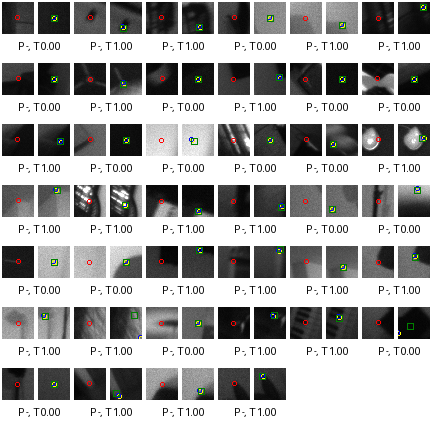

In [17]:
batch = next(iter(dl))
ref_patches, references, tar_patches, targets, estimates, confidences = batch

print(f'{references.shape=}')

count = 24 * 2

from utils import show_batch
show_batch(
    ref_patches, tar_patches,
    references, estimates, targets,

    confidences_true=confidences,
    estimates=estimates,

    limit_count=count,

    n_columns=6,
    just_gt=False,
)

# Light

In [21]:
# torch.cuda.empty_cache()

from src import Light
light = Light()

from utils import count_params
num = count_params(light.model)
print(f"{num:,}")

6,067,689


In [22]:
pred = light(
    ref_patches, 
    tar_patches, 
    # references,
    estimates,
)

# target_coords = pred
# target_confidences = pred
target_coords, target_confidences = pred

print(f'{target_coords.shape=}')
print(f'{target_confidences.shape=}')

target_coords.shape=torch.Size([40, 2])
target_confidences.shape=torch.Size([40])


In [23]:
d = light._shared_step(batch)